# Student Performance Prediction - Regression Models Comparison

This notebook demonstrates various regression techniques to predict student performance using a dataset with minimal multicollinearity.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Download Dataset from Kaggle

**Note:** Make sure you have Kaggle API credentials set up at `~/.kaggle/kaggle.json`
If not, download manually from: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

In [2]:
import os
from pathlib import Path

csv_path = 'Student_Performance.csv'

# Check if file already exists
if os.path.exists(csv_path):
    print(f"Dataset found at {csv_path}")
else:
    print("Attempting to download from Kaggle...")
    try:
        # Using Kaggle CLI to download the dataset
        os.system('kaggle datasets download -d nikhil7280/student-performance-multiple-linear-regression')
        # Unzip the downloaded file
        import zipfile
        with zipfile.ZipFile('student-performance-multiple-linear-regression.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
        print("Dataset downloaded and extracted successfully!")
    except Exception as e:
        print(f"Error: {e}")
        print("Please download manually from Kaggle and ensure the CSV is in the current directory")

Dataset found at Student_Performance.csv


## 3. Load and Explore the Data

In [3]:
# Load the dataset
df = pd.read_csv('Student_Performance.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (10000, 6)

First few rows:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   

## 4. Data Preprocessing & Categorical Encoding

In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any
df = df.dropna()

# Identify categorical and numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Encode categorical variables
df_encoded = df.copy()

# Use Label Encoding for binary categorical variables (Yes/No)
for col in categorical_cols:
    if df_encoded[col].nunique() == 2:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"\nEncoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")
    else:
        # For non-binary categorical: One-hot encode
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True)

print(f"\nDataset shape after encoding: {df_encoded.shape}")
print(f"\nEncoded columns:")
print(df_encoded.columns.tolist())

Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Categorical columns: ['Extracurricular Activities']
Numeric columns: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

Encoded 'Extracurricular Activities': {'No': np.int64(0), 'Yes': np.int64(1)}

Dataset shape after encoding: (10000, 6)

Encoded columns:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


## 5. Prepare Features and Target

In [5]:
# Identify features and target from encoded data
X = df_encoded.iloc[:, :-1]  # All columns except the last (target)
y = df_encoded.iloc[:, -1]   # Last column is target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"Target column: {df_encoded.columns[-1]}")
print(f"\nFirst few samples:")
print(X.head())

Features (X) shape: (10000, 5)
Target (y) shape: (10000,)

Feature columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
Target column: Performance Index

First few samples:
   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  


## 6. Correlation Analysis - Check for Multicollinearity

Correlation Matrix:
                                  Hours Studied  Previous Scores  \
Hours Studied                          1.000000        -0.012390   
Previous Scores                       -0.012390         1.000000   
Extracurricular Activities             0.003873         0.008369   
Sleep Hours                            0.001245         0.005944   
Sample Question Papers Practiced       0.017463         0.007888   
Performance Index                      0.373730         0.915189   

                                  Extracurricular Activities  Sleep Hours  \
Hours Studied                                       0.003873     0.001245   
Previous Scores                                     0.008369     0.005944   
Extracurricular Activities                          1.000000    -0.023284   
Sleep Hours                                        -0.023284     1.000000   
Sample Question Papers Practiced                    0.013103     0.003990   
Performance Index                        

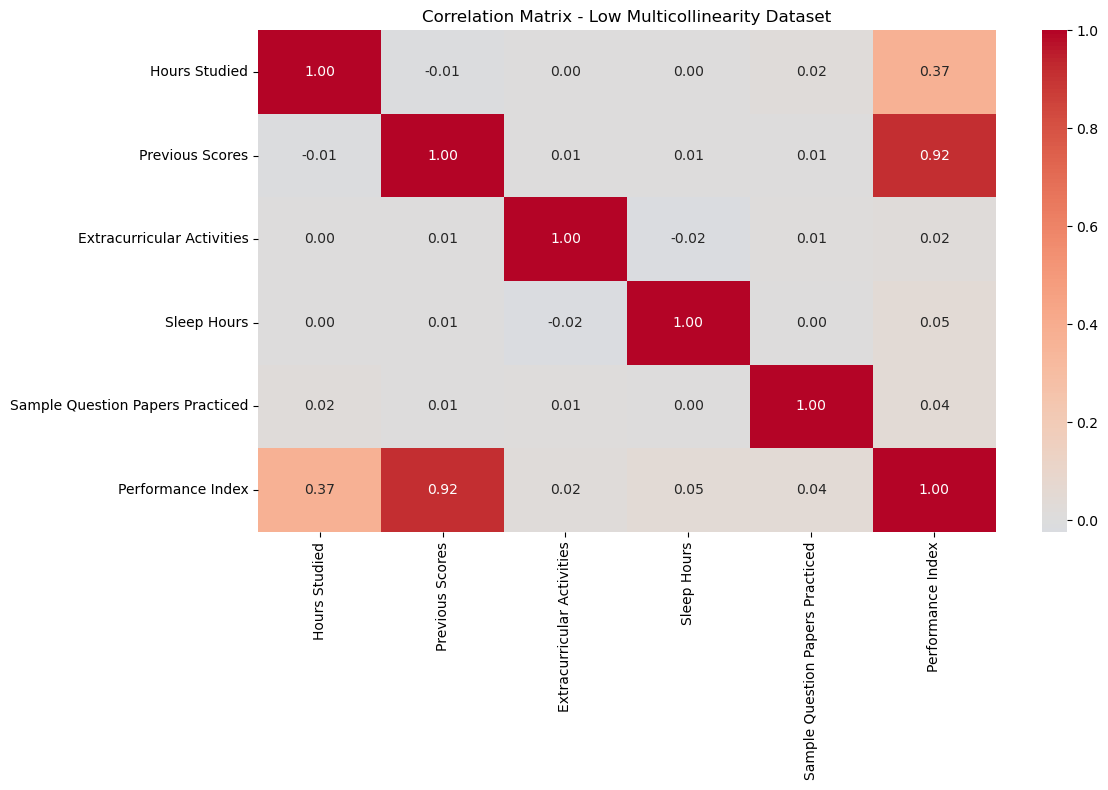


Feature Correlation with Target (Performance Index):
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64


In [6]:
# Correlation matrix (now works with encoded numeric data)
correlation_matrix = df_encoded.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Low Multicollinearity Dataset')
plt.tight_layout()
plt.show()

# Check feature correlation with target
print("\nFeature Correlation with Target (Performance Index):")
target_corr = correlation_matrix.iloc[:, -1].sort_values(ascending=False)
print(target_corr)

## 7. Train-Test Split and Scaling

In [7]:
# Split the data: 80% training, 20% testing
random_state_seed = 42
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state_seed
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Standardize features (important for algorithms like KNN, SVM, Ridge, Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled successfully!")
print(f"Feature mean (should be ~0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"Feature std (should be ~1): {X_train_scaled.std(axis=0)[:3]}")

Training set size: 8000
Testing set size: 2000

Data scaled successfully!
Feature mean (should be ~0): [ 2.84217094e-17 -3.32178729e-16  5.15143483e-17]
Feature std (should be ~1): [1. 1. 1.]


## 8. Linear Regression

### Formula:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Where:
- $y$ = predicted target (student performance)
- $\beta_0$ = intercept (bias term)
- $\beta_i$ = coefficients for each feature
- $x_i$ = input features
- $\epsilon$ = error term

### Objective:
Minimize the sum of squared errors (SSE): $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

In [8]:
# Train Linear Regression model
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

print("Linear Regression Model Parameters:")
print(f"Intercept (β₀): {lr_model.intercept_:.4f}")
print(f"\nCoefficients (β₁, β₂, ...):")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")

Linear Regression Model Parameters:
Intercept (β₀): 55.3115

Coefficients (β₁, β₂, ...):
  Hours Studied: 7.4013
  Previous Scores: 17.6373
  Extracurricular Activities: 0.3043
  Sleep Hours: 0.8100
  Sample Question Papers Practiced: 0.5488


## 9. Ridge Regression (L2 Regularization)

### Formula:
$$J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

Where:
- $\lambda$ (alpha) = regularization parameter (controls penalty strength)
- $\sum \beta_j^2$ = L2 penalty (sum of squared coefficients)

### Purpose:
Prevents overfitting by penalizing large coefficients. Useful when features are correlated.

In [9]:
# Train Ridge Regression model
alpha_ridge = 1.0  # Regularization parameter
ridge_model = Ridge(alpha=alpha_ridge, random_state=random_state_seed)
ridge_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge_test = ridge_model.predict(X_test_scaled)

print(f"Ridge Regression Model Parameters (α={alpha_ridge}):")
print(f"Intercept: {ridge_model.intercept_:.4f}")
print(f"\nCoefficients (with L2 penalty):")
for feature, coef in zip(X.columns, ridge_model.coef_):
    print(f"  {feature}: {coef:.4f}")

Ridge Regression Model Parameters (α=1.0):
Intercept: 55.3115

Coefficients (with L2 penalty):
  Hours Studied: 7.4004
  Previous Scores: 17.6351
  Extracurricular Activities: 0.3043
  Sleep Hours: 0.8099
  Sample Question Papers Practiced: 0.5488


## 10. Lasso Regression (L1 Regularization)

### Formula:
$$J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

Where:
- $\lambda$ (alpha) = regularization parameter
- $\sum |\beta_j|$ = L1 penalty (sum of absolute coefficients)

### Purpose:
Feature selection - can shrink some coefficients to exactly zero, eliminating less important features.

In [10]:
# Train Lasso Regression model
alpha_lasso = 0.01  # Regularization parameter
lasso_model = Lasso(alpha=alpha_lasso, random_state=random_state_seed, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso_test = lasso_model.predict(X_test_scaled)

print(f"Lasso Regression Model Parameters (α={alpha_lasso}):")
print(f"Intercept: {lasso_model.intercept_:.4f}")
print(f"\nCoefficients (L1 penalty - some may be zero):")
for feature, coef in zip(X.columns, lasso_model.coef_):
    status = "(zeroed out)" if coef == 0 else ""
    print(f"  {feature}: {coef:.4f} {status}")

Lasso Regression Model Parameters (α=0.01):
Intercept: 55.3115

Coefficients (L1 penalty - some may be zero):
  Hours Studied: 7.3915 
  Previous Scores: 17.6273 
  Extracurricular Activities: 0.2941 
  Sleep Hours: 0.7999 
  Sample Question Papers Practiced: 0.5391 


## 11. Elastic Net Regression (Combined L1 & L2)

### Formula:
$$J(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \left[ (1-\rho) \frac{\sum |\beta_j|}{2} + \rho \frac{\sum \beta_j^2}{2} \right]$$

Where:
- $\lambda$ = regularization strength
- $\rho$ (l1_ratio) = balance between L1 (0) and L2 (1)

### Purpose:
Combines benefits of Ridge and Lasso for feature selection with correlation handling.

In [11]:
# Train Elastic Net model
alpha_elasticnet = 0.01
l1_ratio = 0.5  # 0.5 = equal L1 and L2 penalty
elasticnet_model = ElasticNet(alpha=alpha_elasticnet, l1_ratio=l1_ratio, 
                               random_state=random_state_seed, max_iter=10000)
elasticnet_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_elasticnet_train = elasticnet_model.predict(X_train_scaled)
y_pred_elasticnet_test = elasticnet_model.predict(X_test_scaled)

print(f"Elastic Net Model Parameters (α={alpha_elasticnet}, ρ={l1_ratio}):")
print(f"Intercept: {elasticnet_model.intercept_:.4f}")
print(f"\nCoefficients (L1+L2 penalty):")
for feature, coef in zip(X.columns, elasticnet_model.coef_):
    status = "(zeroed out)" if coef == 0 else ""
    print(f"  {feature}: {coef:.4f} {status}")

Elastic Net Model Parameters (α=0.01, ρ=0.5):
Intercept: 55.3115

Coefficients (L1+L2 penalty):
  Hours Studied: 7.3587 
  Previous Scores: 17.5442 
  Extracurricular Activities: 0.2980 
  Sleep Hours: 0.8012 
  Sample Question Papers Practiced: 0.5427 


## 12. Polynomial Regression

### Formula:
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_d x^d + \epsilon$$

Where:
- $d$ = polynomial degree (complexity)
- Creates non-linear relationships between features and target

### Note:
We'll create polynomial features and use LinearRegression to fit

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
polynomial_degree = 2  # degree of polynomial
poly_features = PolynomialFeatures(degree=polynomial_degree, include_bias=False)

X_train_poly = poly_features.fit_transform(X_train_scaled)
X_test_poly = poly_features.transform(X_test_scaled)

# Train polynomial regression model
poly_model = LinearRegression(fit_intercept=True)
poly_model.fit(X_train_poly, y_train)

# Make predictions
y_pred_poly_train = poly_model.predict(X_train_poly)
y_pred_poly_test = poly_model.predict(X_test_poly)

print(f"Polynomial Regression Model Parameters (degree={polynomial_degree}):")
print(f"Intercept: {poly_model.intercept_:.4f}")
print(f"Number of features after polynomial expansion: {X_train_poly.shape[1]}")
print(f"Number of coefficients: {len(poly_model.coef_)}")
print(f"\nFirst 5 coefficients: {poly_model.coef_[:5]}")

Polynomial Regression Model Parameters (degree=2):
Intercept: 55.2880
Number of features after polynomial expansion: 20
Number of coefficients: 20

First 5 coefficients: [ 7.40206705 17.63690688  0.30514719  0.81108233  0.54850973]


## 13. K-Nearest Neighbors (KNN) Regressor

### Formula:
$$\hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i$$

Where:
- $k$ = number of nearest neighbors to consider
- Prediction is the average of k nearest neighbors' values

### Key Parameters:
- **n_neighbors (k)**: Number of neighbors (default=5). Larger k = smoother predictions
- **weights**: 'uniform' (all neighbors equal) or 'distance' (closer neighbors weighted more)

### Distance Metric:
Usually Euclidean distance: $d = \sqrt{\sum (x_{1i} - x_{2i})^2}$

In [13]:
# Train KNN Regressor
n_neighbors = 5  # Number of neighbors to consider
weights_type = 'distance'  # 'uniform' or 'distance'

knn_model = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights_type)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn_train = knn_model.predict(X_train_scaled)
y_pred_knn_test = knn_model.predict(X_test_scaled)

print(f"KNN Regressor Model Parameters:")
print(f"  k (n_neighbors): {n_neighbors}")
print(f"  Weight type: {weights_type}")
print(f"  Distance metric: Euclidean")
print(f"  Samples in training set: {X_train_scaled.shape[0]}")

KNN Regressor Model Parameters:
  k (n_neighbors): 5
  Weight type: distance
  Distance metric: Euclidean
  Samples in training set: 8000


## 14. Support Vector Machine (SVM) Regressor

### Formula:
$$f(x) = w^T \phi(x) + b$$

Where:
- $w$ = weight vector
- $\phi(x)$ = kernel function (transforms data to higher dimension)
- $b$ = bias term

### Objective:
$$\min_{w,b,\xi} \frac{1}{2}||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

### Key Parameters:
- **C**: Penalty for errors (higher C = less tolerance for errors)
- **kernel**: 'linear', 'rbf', 'poly' (affects decision boundary complexity)
- **epsilon (ε)**: Margin of tolerance (how much error is acceptable)

In [14]:
# Train SVM Regressor
C_svm = 100  # Penalty parameter
kernel_type = 'rbf'  # 'linear', 'rbf', 'poly'
epsilon = 0.1  # Margin of tolerance

svm_model = SVR(C=C_svm, kernel=kernel_type, epsilon=epsilon, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm_train = svm_model.predict(X_train_scaled)
y_pred_svm_test = svm_model.predict(X_test_scaled)

print(f"SVM Regressor Model Parameters:")
print(f"  C (penalty): {C_svm}")
print(f"  Kernel: {kernel_type}")
print(f"  Epsilon (ε): {epsilon}")
print(f"  Support vectors: {len(svm_model.support_)}")
print(f"  Total training samples: {X_train_scaled.shape[0]}")

SVM Regressor Model Parameters:
  C (penalty): 100
  Kernel: rbf
  Epsilon (ε): 0.1
  Support vectors: 7650
  Total training samples: 8000


## 15. Random Forest Regressor

### Concept:
Ensemble of decision trees. Each tree predicts independently, final prediction is average.

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

Where:
- $B$ = number of trees
- $T_b(x)$ = prediction from tree b

### Key Parameters:
- **n_estimators**: Number of trees in forest
- **max_depth**: Maximum tree depth (prevents overfitting)
- **min_samples_split**: Minimum samples to split a node
- **max_features**: Number of features to consider at each split

### Advantages:
- Non-linear relationships
- Feature importance ranking
- Robust to outliers

In [15]:
# Train Random Forest Regressor
n_estimators = 100  # Number of trees
max_depth = 10  # Maximum tree depth
min_samples_split = 5  # Minimum samples to split
max_features = 'sqrt'  # Features to consider at each split

rf_model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    max_features=max_features,
    random_state=random_state_seed,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

print(f"Random Forest Regressor Model Parameters:")
print(f"  n_estimators: {n_estimators}")
print(f"  max_depth: {max_depth}")
print(f"  min_samples_split: {min_samples_split}")
print(f"  max_features: {max_features}")

# Feature Importance
print(f"\nFeature Importance:")
for feature, importance in zip(X.columns, rf_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

Random Forest Regressor Model Parameters:
  n_estimators: 100
  max_depth: 10
  min_samples_split: 5
  max_features: sqrt

Feature Importance:
  Hours Studied: 0.1415
  Previous Scores: 0.8439
  Extracurricular Activities: 0.0017
  Sleep Hours: 0.0060
  Sample Question Papers Practiced: 0.0069


## 16. Gradient Boosting Regressor

### Concept:
Sequentially builds trees, each new tree corrects errors from previous trees.

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

Where:
- $F_{m-1}(x)$ = previous ensemble prediction
- $\nu$ (learning_rate) = step size (0 < ν ≤ 1)
- $h_m(x)$ = new tree correcting previous errors

### Key Parameters:
- **n_estimators**: Number of boosting stages
- **learning_rate**: Shrinks contribution of each tree (lower = more robust but slower)
- **max_depth**: Depth of individual trees (usually small, 3-8)
- **subsample**: Fraction of samples for training each tree

### Advantages:
- Very accurate for complex non-linear relationships
- Less prone to overfitting than Random Forest
- Often wins Kaggle competitions

In [16]:
# Train Gradient Boosting Regressor
n_estimators_gb = 100  # Number of boosting stages
learning_rate = 0.1  # Shrinkage parameter (0 < lr <= 1)
max_depth_gb = 5  # Depth of individual trees
min_samples_split_gb = 5
subsample = 0.8  # Fraction of samples for training each tree

gb_model = GradientBoostingRegressor(
    n_estimators=n_estimators_gb,
    learning_rate=learning_rate,
    max_depth=max_depth_gb,
    min_samples_split=min_samples_split_gb,
    subsample=subsample,
    random_state=random_state_seed
)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb_train = gb_model.predict(X_train_scaled)
y_pred_gb_test = gb_model.predict(X_test_scaled)

print(f"Gradient Boosting Regressor Model Parameters:")
print(f"  n_estimators: {n_estimators_gb}")
print(f"  learning_rate: {learning_rate}")
print(f"  max_depth: {max_depth_gb}")
print(f"  min_samples_split: {min_samples_split_gb}")
print(f"  subsample: {subsample}")

# Feature Importance
print(f"\nFeature Importance:")
for feature, importance in zip(X.columns, gb_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")

Gradient Boosting Regressor Model Parameters:
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 5
  min_samples_split: 5
  subsample: 0.8

Feature Importance:
  Hours Studied: 0.1452
  Previous Scores: 0.8511
  Extracurricular Activities: 0.0003
  Sleep Hours: 0.0022
  Sample Question Papers Practiced: 0.0013


## 17. Evaluation Metrics

### 17.1 Mean Squared Error (MSE)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- Measures average squared difference between actual and predicted values
- Units: squared units of target variable
- Penalizes larger errors more heavily (quadratic penalty)
- Lower is better

### 17.2 Root Mean Squared Error (RMSE)

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- Square root of MSE
- Units: same as target variable (more interpretable than MSE)
- Measures average prediction error magnitude
- Lower is better

### 17.3 R² Score (Coefficient of Determination)

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Where:
- $SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ = residual sum of squares
- $SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2$ = total sum of squares

- Proportion of variance explained by the model
- Range: [0, 1] (can be negative for poor models)
- 0 = model explains no variance
- 1 = model explains all variance
- Higher is better

In [17]:
# Function to calculate and display metrics
def evaluate_model(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    # Training metrics
    mse_train = mean_squared_error(y_train_true, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_true, y_train_pred)
    
    # Testing metrics
    mse_test = mean_squared_error(y_test_true, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test_true, y_test_pred)
    
    return {
        'Model': model_name,
        'Train MSE': mse_train,
        'Test MSE': mse_test,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Train R²': r2_train,
        'Test R²': r2_test
    }

# Evaluate all models
results = []
results.append(evaluate_model('Linear Regression', y_train, y_pred_lr_train, y_test, y_pred_lr_test))
results.append(evaluate_model('Ridge Regression', y_train, y_pred_ridge_train, y_test, y_pred_ridge_test))
results.append(evaluate_model('Lasso Regression', y_train, y_pred_lasso_train, y_test, y_pred_lasso_test))
results.append(evaluate_model('Elastic Net', y_train, y_pred_elasticnet_train, y_test, y_pred_elasticnet_test))
results.append(evaluate_model('Polynomial Regression', y_train, y_pred_poly_train, y_test, y_pred_poly_test))
results.append(evaluate_model('KNN Regressor', y_train, y_pred_knn_train, y_test, y_pred_knn_test))
results.append(evaluate_model('SVM Regressor', y_train, y_pred_svm_train, y_test, y_pred_svm_test))
results.append(evaluate_model('Random Forest', y_train, y_pred_rf_train, y_test, y_pred_rf_test))
results.append(evaluate_model('Gradient Boosting', y_train, y_pred_gb_train, y_test, y_pred_gb_test))

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*120)
print("MODEL EVALUATION RESULTS")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)


MODEL EVALUATION RESULTS
                Model  Train MSE  Test MSE  Train RMSE  Test RMSE  Train R²  Test R²
    Linear Regression   4.169736  4.082628    2.041993   2.020552  0.988690 0.988983
     Ridge Regression   4.169742  4.083211    2.041995   2.020696  0.988690 0.988982
     Lasso Regression   4.170235  4.087239    2.042115   2.021692  0.988689 0.988971
          Elastic Net   4.180318  4.118189    2.044583   2.029332  0.988661 0.988887
Polynomial Regression   4.164290  4.080643    2.040659   2.020060  0.988705 0.988989
        KNN Regressor   0.256375  8.031080    0.506335   2.833916  0.999305 0.978329
        SVM Regressor   4.032377  4.342580    2.008078   2.083886  0.989062 0.988282
        Random Forest   3.731263  5.753299    1.931648   2.398603  0.989879 0.984475
    Gradient Boosting   3.692017  4.294704    1.921462   2.072367  0.989986 0.988411


## 18. Model Comparison Visualization

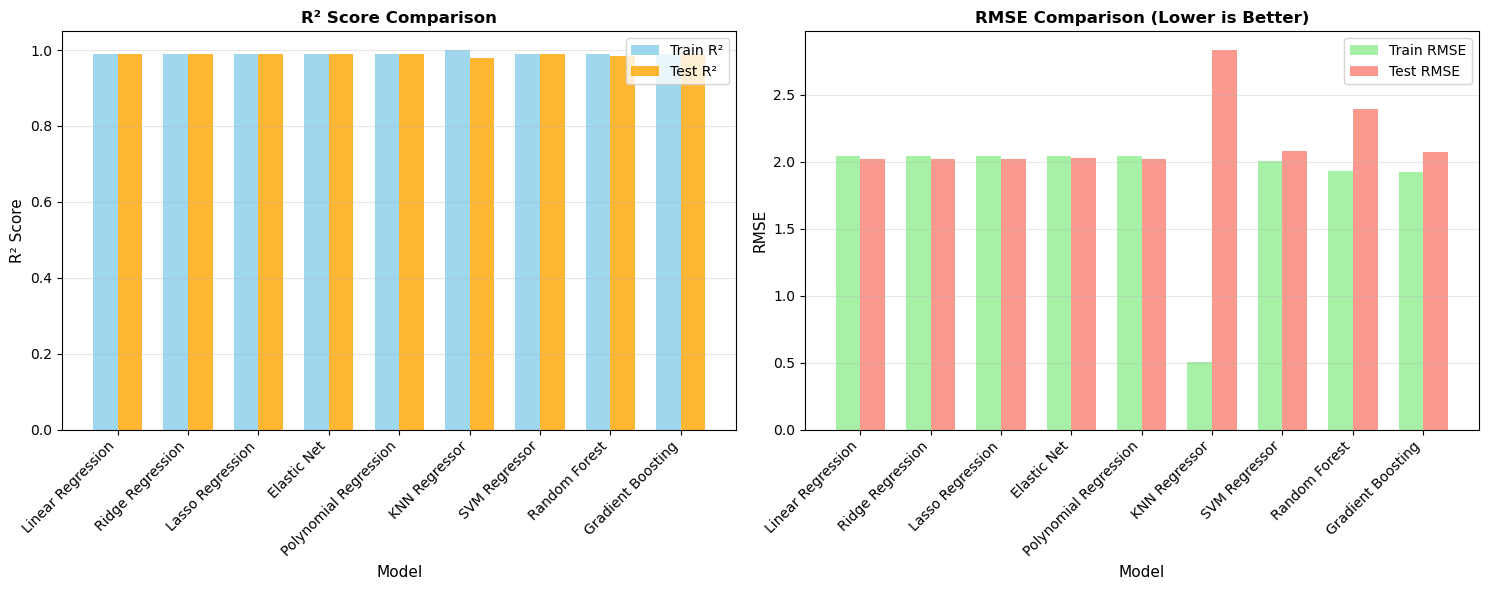

In [18]:
# Plot R² scores
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R² comparison
ax1 = axes[0]
models = results_df['Model']
train_r2 = results_df['Train R²']
test_r2 = results_df['Test R²']

x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, train_r2, width, label='Train R²', alpha=0.8, color='skyblue')
ax1.bar(x + width/2, test_r2, width, label='Test R²', alpha=0.8, color='orange')
ax1.set_xlabel('Model', fontsize=11)
ax1.set_ylabel('R² Score', fontsize=11)
ax1.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# RMSE comparison
ax2 = axes[1]
train_rmse = results_df['Train RMSE']
test_rmse = results_df['Test RMSE']

ax2.bar(x - width/2, train_rmse, width, label='Train RMSE', alpha=0.8, color='lightgreen')
ax2.bar(x + width/2, test_rmse, width, label='Test RMSE', alpha=0.8, color='salmon')
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('RMSE', fontsize=11)
ax2.set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Summary and Conclusions

### Model Performance Summary:

1. **Best Performing Models** (based on Test R²):
   - Look at the highest Test R² score in results
   - This indicates the best generalization to unseen data

2. **Underfitting vs Overfitting**:
   - If Train R² >> Test R² : Model is overfitting
   - If Train R² ≈ Test R² : Model generalizes well
   - If both are low : Model is underfitting

3. **Model Interpretability**:
   - **Linear models (LR, Ridge, Lasso)**: Easy to interpret, coefficient values are meaningful
   - **Tree-based models (RF, GB)**: Provide feature importance
   - **KNN, SVM**: Black-box models, harder to interpret

4. **Computational Complexity**:
   - **Fast**: Linear models, KNN
   - **Medium**: Polynomial, SVM
   - **Slow**: Random Forest, Gradient Boosting

5. **Recommendation**:
   - Use ensemble models (RF, GB) when accuracy is priority
   - Use regularized linear models (Ridge, Lasso) for interpretability
   - Use KNN/SVM for medium-sized datasets with non-linear relationships

In [19]:
# Best model selection
best_model_idx = results_df['Test R²'].idxmax()
best_model = results_df.iloc[best_model_idx]

print("\n" + "="*70)
print("BEST PERFORMING MODEL")
print("="*70)
print(f"Model: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.4f}")
print(f"Test RMSE: {best_model['Test RMSE']:.4f}")
print(f"Train R²: {best_model['Train R²']:.4f}")
print(f"Train RMSE: {best_model['Train RMSE']:.4f}")
print(f"\nOverfitting Status: ", end="")
diff = best_model['Train R²'] - best_model['Test R²']
if diff > 0.1:
    print("⚠️ Overfitting detected (Train R² >> Test R²)")
elif diff < 0.05:
    print("✓ Good generalization (Train R² ≈ Test R²)")
else:
    print("△ Moderate overfitting")
print("="*70)


BEST PERFORMING MODEL
Model: Polynomial Regression
Test R²: 0.9890
Test RMSE: 2.0201
Train R²: 0.9887
Train RMSE: 2.0407

Overfitting Status: ✓ Good generalization (Train R² ≈ Test R²)
